DATASET OVERVIEW
Shape: (1000, 11)

Columns: ['income', 'house_price', 'purchases', 'sales_revenue', 'exam_scores', 'customer_rating', 'age', 'square_footage', 'website_visits', 'insurance_claim', 'target']

Missing Values: 0

First 5 rows:
          income    house_price  purchases  sales_revenue  exam_scores  \
0   23463.404499  190676.453786         23    4642.521700    74.253590   
1  150506.071546   46881.486665         25    1637.112867    92.234516   
2   65837.284677  249884.069507         10  381429.416515    96.244185   
3   45647.127689  348752.892337         18  233374.434768    89.237683   
4    8481.243523  157771.428807         32    9286.651891    88.060943   

   customer_rating        age  square_footage  website_visits  \
0         3.735216  41.069574     1751.281122             897   
1         3.119885  22.525745     1064.783460             180   
2         2.595988  32.906281     1122.728522               0   
3         3.036372  58.637493     1237.527114         

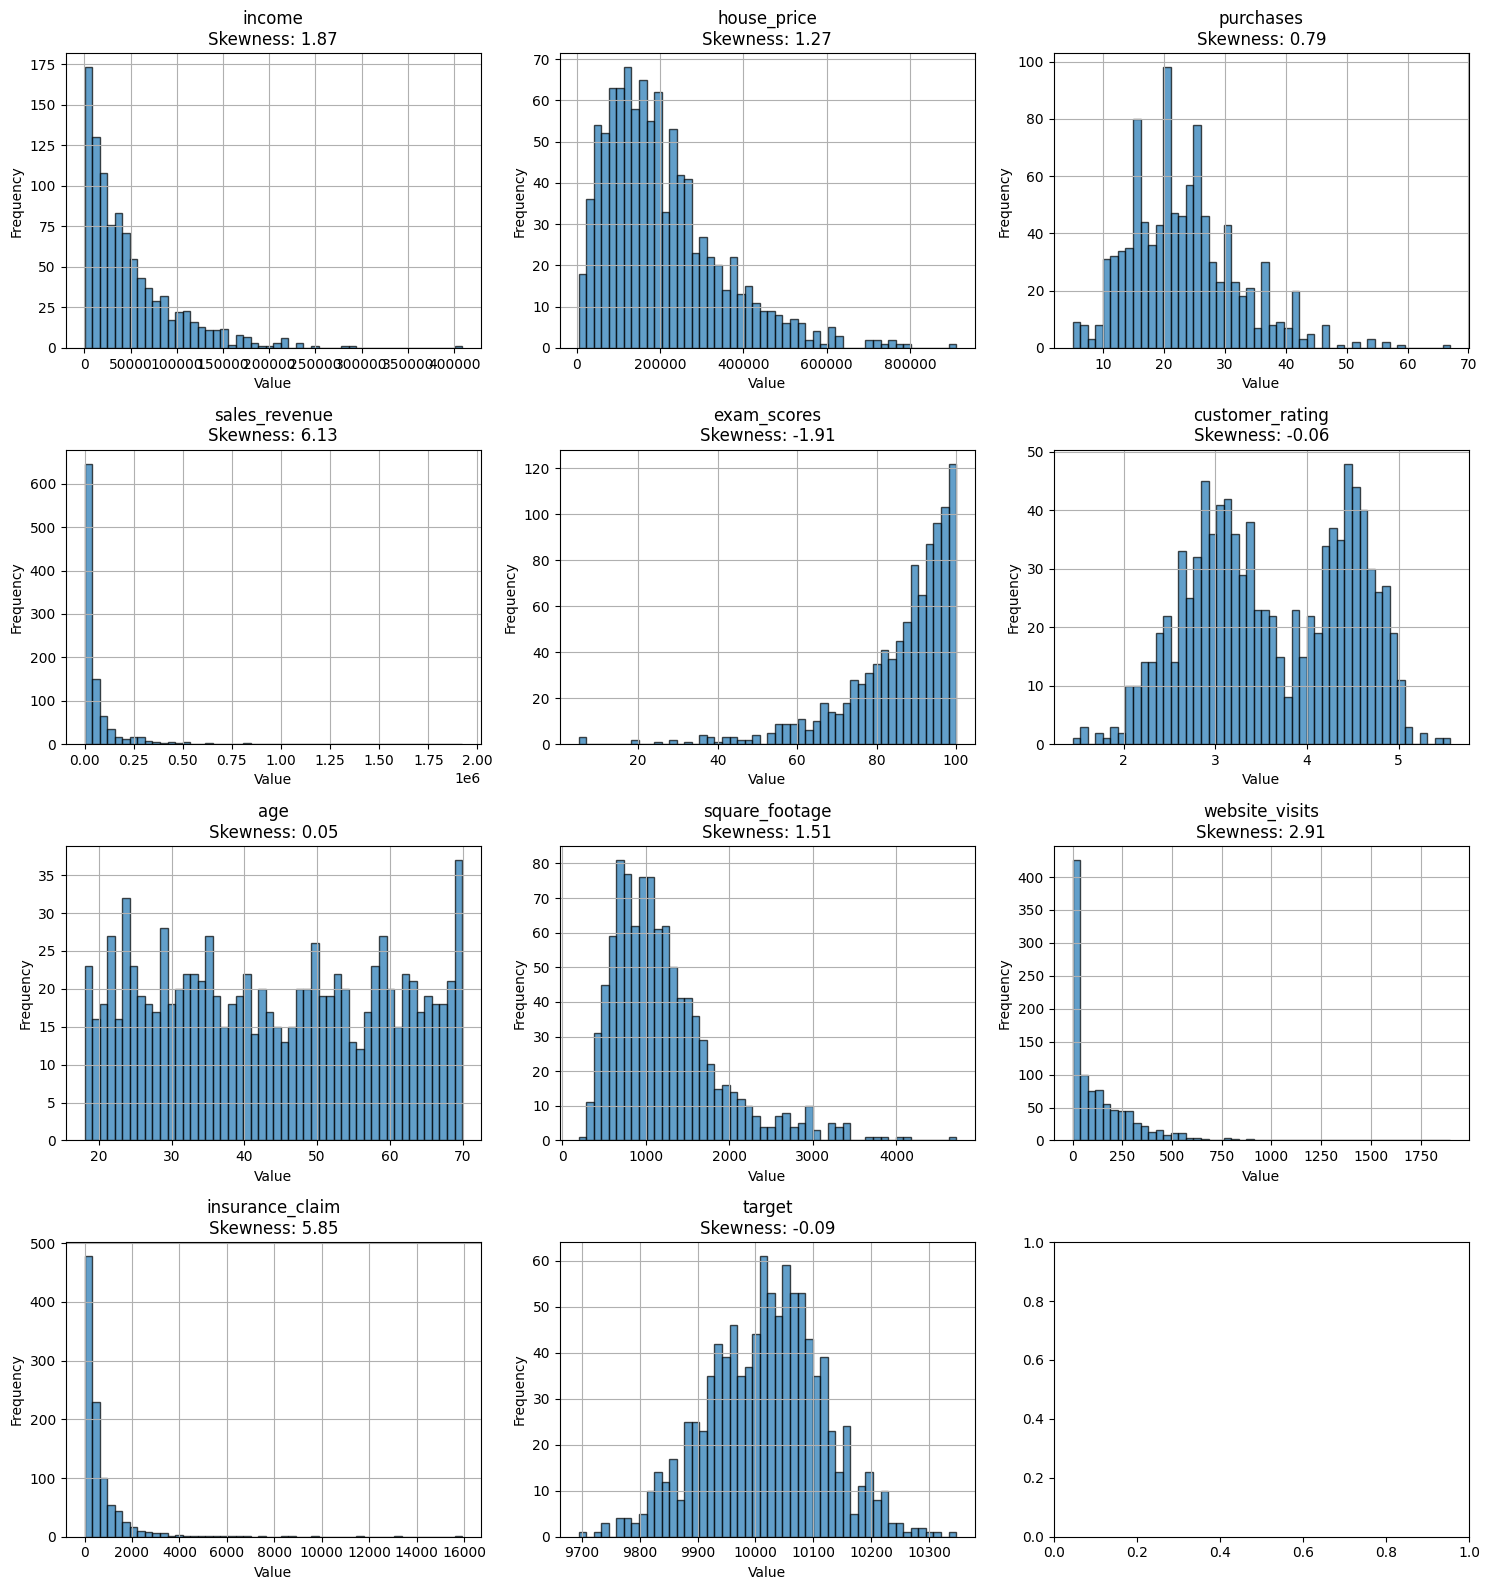

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    FunctionTransformer,
    PowerTransformer,
    QuantileTransformer,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# ============================================
# CREATE DATASET WITH VARIOUS DISTRIBUTIONS
# ============================================

n = 1000

data = pd.DataFrame(
    {
        # 1. RIGHT-SKEWED (Exponential) - Good for LOG transformation
        "income": np.random.exponential(scale=50000, size=n),
        # 2. RIGHT-SKEWED with outliers - Good for LOG or POWER
        "house_price": np.random.gamma(shape=2, scale=100000, size=n),
        # 3. COUNT DATA with many zeros - Good for LOG1P
        "purchases": np.random.negative_binomial(n=10, p=0.3, size=n),
        # 4. HIGHLY SKEWED (Lognormal) - Good for LOG or BOX-COX
        "sales_revenue": np.random.lognormal(mean=10, sigma=1.5, size=n),
        # 5. LEFT-SKEWED - Good for SQUARE ROOT or POWER
        "exam_scores": 100 - np.random.exponential(scale=15, size=n).clip(0, 95),
        # 6. BIMODAL - Good for QUANTILE transformation
        "customer_rating": np.concatenate(
            [
                np.random.normal(3, 0.5, int(n * 0.6)),
                np.random.normal(4.5, 0.3, int(n * 0.4)),
            ]
        )[:n],
        # 7. UNIFORM - No transformation needed (control)
        "age": np.random.uniform(18, 70, size=n),
        # 8. MULTIPLICATIVE RELATIONSHIP - Good for LOG
        "square_footage": np.random.lognormal(mean=7, sigma=0.5, size=n),
        # 9. ZERO-INFLATED - Good for LOG1P or QUANTILE
        "website_visits": np.where(
            np.random.random(n) < 0.3, 0, np.random.exponential(scale=200, size=n)
        ).astype(int),
        # 10. HEAVY-TAILED - Good for POWER or QUANTILE
        "insurance_claim": np.random.pareto(a=2.5, size=n) * 1000,
    }
)

# Add a target variable that's a function of transformed features
data["target"] = (
    10000
    + 0.5 * np.log1p(data["income"])
    + 0.3 * np.log1p(data["house_price"])
    + 0.2 * np.sqrt(data["exam_scores"])
    + 0.1 * data["age"]
    + np.random.normal(0, 100, n)
)

# ============================================
# DISPLAY DATASET INFO
# ============================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nMissing Values: {data.isnull().sum().sum()}")
print("\nFirst 5 rows:")
print(data.head())

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(data.describe())

print("\n" + "=" * 60)
print("SKEWNESS VALUES (Before Transformation)")
print("=" * 60)
print(data.skew().round(3))

# ============================================
# SAVE DATASET (Optional)
# ============================================

# Save to CSV for later use
data.to_csv("practice_dataset.csv", index=False)
print("\n✅ Dataset saved as 'practice_dataset.csv'")

# ============================================
# VISUALIZE DISTRIBUTIONS
# ============================================

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    if i < len(axes):
        data[col].hist(bins=50, ax=axes[i], edgecolor="black", alpha=0.7)
        axes[i].set_title(f"{col}\nSkewness: {data[col].skew():.2f}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("practice_dataset.csv")

In [3]:
df.head()

,income,house_price,purchases,sales_revenue,exam_scores,customer_rating,age,square_footage,website_visits,insurance_claim,target
0,23463.404499,190676.453786,23,4642.521700,74.253590,3.735216,41.069574,1751.281122,897,811.287693,9940.614387
1,150506.071546,46881.486665,25,1637.112867,92.234516,3.119885,22.525745,1064.783460,180,67.074858,9887.590454
2,65837.284677,249884.069507,10,381429.416515,96.244185,2.595988,32.906281,1122.728522,0,264.793984,10133.163139
3,45647.127689,348752.892337,18,233374.434768,89.237683,3.036372,58.637493,1237.527114,0,80.963912,10098.826694
4,8481.243523,157771.428807,32,9286.651891,88.060943,2.420758,25.882571,675.914972,261,543.472102,9986.999483


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   income           1000 non-null   float64
 1   house_price      1000 non-null   float64
 2   purchases        1000 non-null   int64  
 3   sales_revenue    1000 non-null   float64
 4   exam_scores      1000 non-null   float64
 5   customer_rating  1000 non-null   float64
 6   age              1000 non-null   float64
 7   square_footage   1000 non-null   float64
 8   website_visits   1000 non-null   int64  
 9   insurance_claim  1000 non-null   float64
 10  target           1000 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 86.1 KB


In [5]:
df.describe()

,income,house_price,purchases,sales_revenue,exam_scores,customer_rating,age,square_footage,website_visits,insurance_claim,target
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,48625.297398,205625.421275,23.249000,6.648106e+04,85.557652,3.616023,43.844223,1222.915631,132.91100,690.007093,10017.132064
std,48625.494308,139806.780695,8.927188,1.449459e+05,14.242729,0.847324,15.455339,648.959034,184.58569,1232.346176,100.529418
min,232.139203,4591.897611,5.000000,1.452816e+02,5.000000,1.441674,18.008203,194.975240,0.00000,0.101000,9694.395099
25%,13457.826466,102399.644018,17.000000,7.728760e+03,79.859991,2.926909,30.370609,765.769596,0.00000,129.663802,9947.506131
50%,34339.130862,173705.286637,22.000000,2.117287e+04,89.803280,3.526724,43.247614,1070.888741,63.50000,339.177114,10021.733044
75%,68191.510430,270464.327998,28.000000,5.998313e+04,95.765717,4.410687,57.751049,1491.669786,204.00000,742.956080,10084.278534
max,408622.279891,910881.452861,67.000000,1.921434e+06,99.996386,5.563220,69.935002,4715.057479,1899.00000,15910.011897,10346.852855


In [6]:
from scipy import stats
import seaborn as sns

In [7]:
df.columns.value_counts()

,count
income,1
house_price,1
purchases,1
sales_revenue,1
exam_scores,1
customer_rating,1
age,1
square_footage,1
website_visits,1
insurance_claim,1


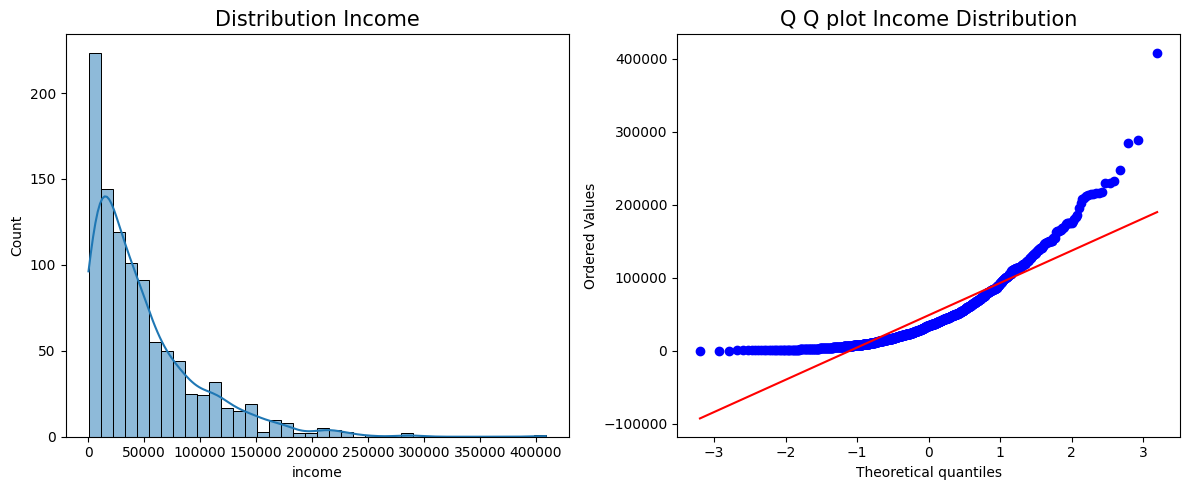

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes.flatten()

sns.histplot(df["income"], ax=axes[0], kde=True)
axes[0].set_title("Distribution Income", fontsize=15)

stats.probplot(df["income"], dist="norm", plot=axes[1])
axes[1].set_title("Q Q plot Income Distribution", fontsize=15)

plt.tight_layout()

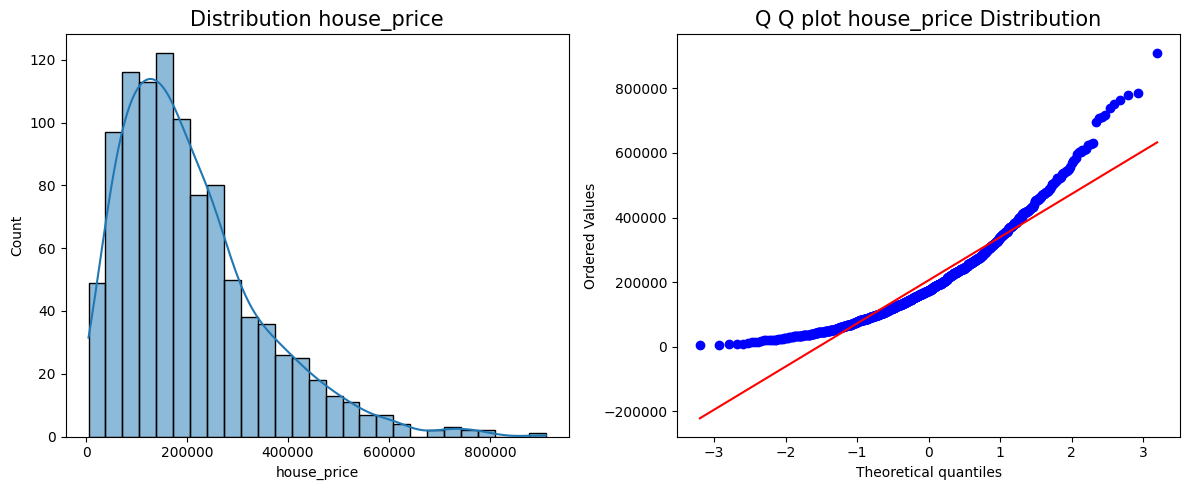

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes.flatten()

sns.histplot(df["house_price"], ax=axes[0], kde=True)
axes[0].set_title("Distribution house_price", fontsize=15)

stats.probplot(df["house_price"], dist="norm", plot=axes[1])
axes[1].set_title("Q Q plot house_price Distribution", fontsize=15)

plt.tight_layout()

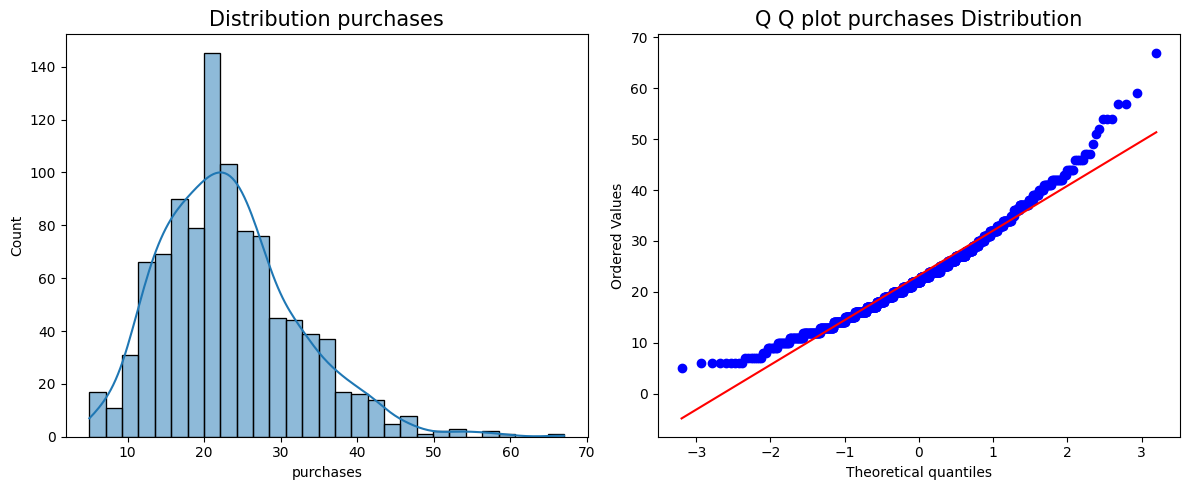

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes.flatten()

sns.histplot(df["purchases"], ax=axes[0], kde=True)
axes[0].set_title("Distribution purchases", fontsize=15)

stats.probplot(df["purchases"], dist="norm", plot=axes[1])
axes[1].set_title("Q Q plot purchases Distribution", fontsize=15)

plt.tight_layout()

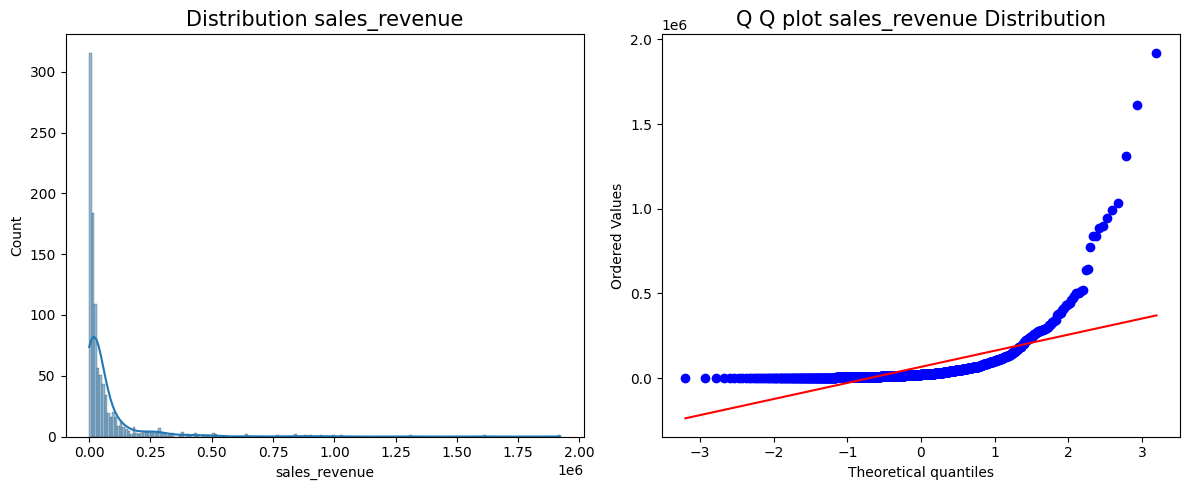

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes.flatten()

sns.histplot(df["sales_revenue"], ax=axes[0], kde=True)
axes[0].set_title("Distribution sales_revenue", fontsize=15)

stats.probplot(df["sales_revenue"], dist="norm", plot=axes[1])
axes[1].set_title("Q Q plot sales_revenue Distribution", fontsize=15)

plt.tight_layout()

In [12]:
columns = df.columns.to_list()
n_col = len(columns)
n_col


11

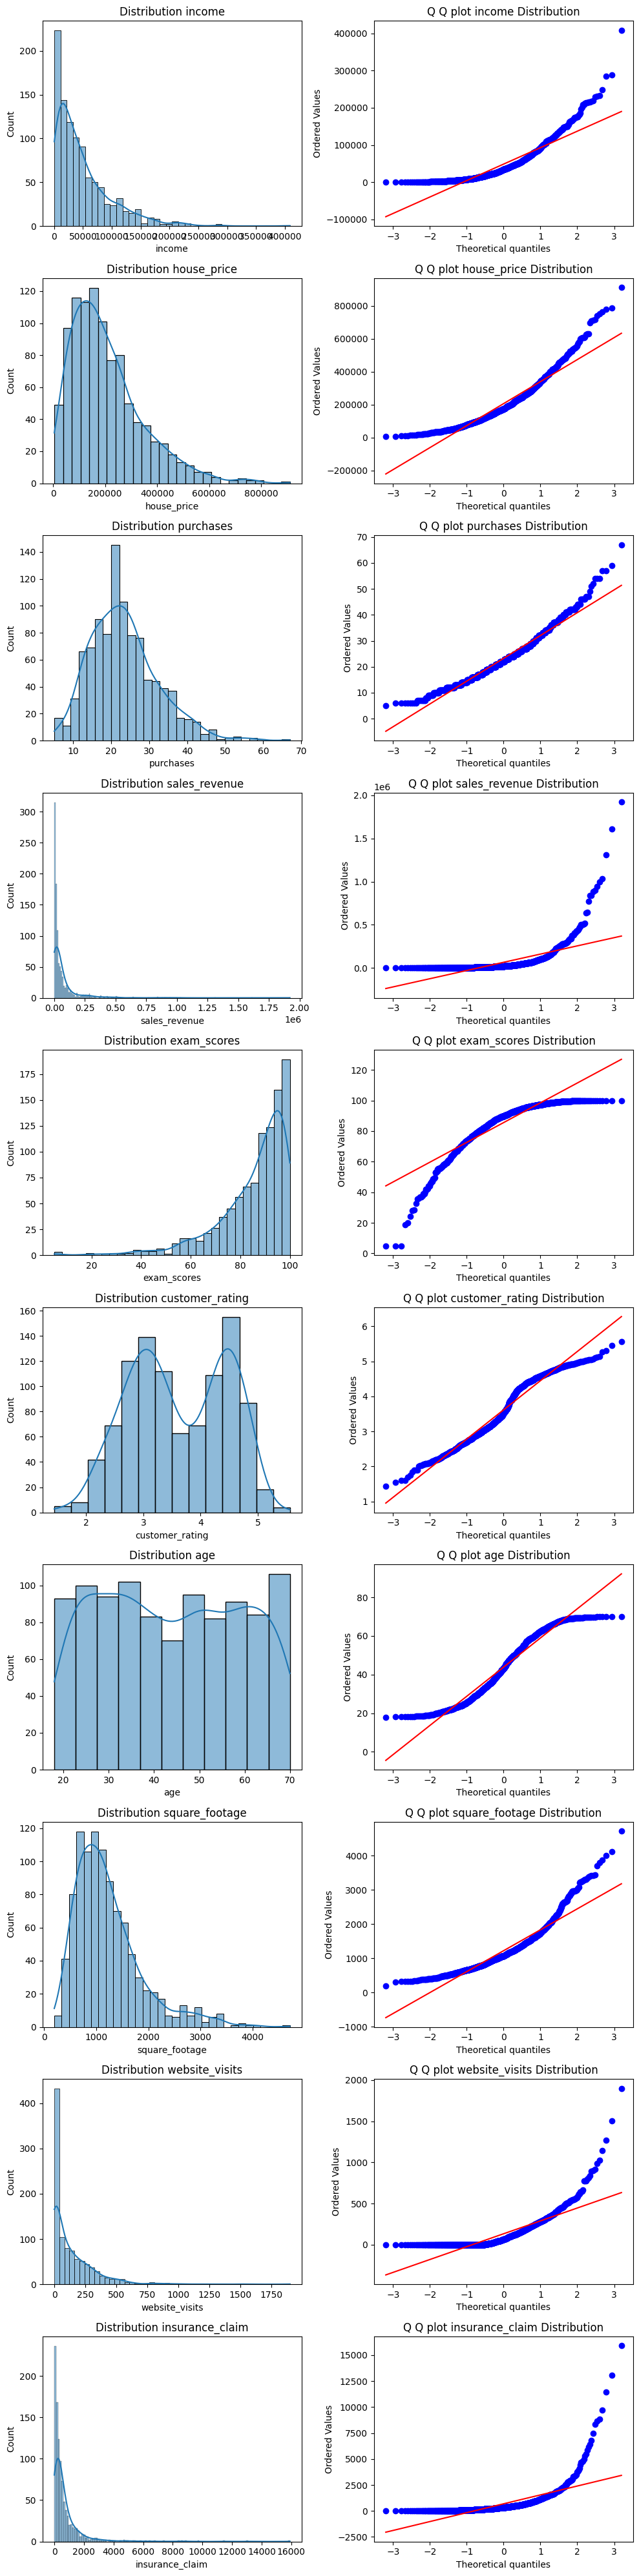

In [13]:
fig, axes = plt.subplots(10, 2, figsize=(10, 40))
axes_flat = axes.flatten()

for i, col in enumerate(columns):

    if i >= 10:
        break

    ax_hist = axes_flat[2 * i]
    sns.histplot(df[col], ax=ax_hist, kde=True)
    ax_hist.set_title(f"Distribution {col}")

    ax_qq = axes_flat[2 * i + 1]
    stats.probplot(df[col], dist="norm", plot=ax_qq)
    ax_qq.set_title(f"Q Q plot {col} Distribution")

plt.tight_layout()

In [14]:
df.columns

X = df.drop("target", axis=1)
y = df["target"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)




In [18]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

-0.01939522783713654

In [19]:
columns

['income',
 'house_price',
 'purchases',
 'sales_revenue',
 'exam_scores',
 'customer_rating',
 'age',
 'square_footage',
 'website_visits',
 'insurance_claim',
 'target']

In [ ]:
right_skewed = [
    "income",
    "house_price",
    "purchases",
    "sales_revenue",
    "customer_rating",
    "age",
    "square_footage",
    "website_visits",
    "insurance_claim",
]

left_skewed = [
    "exam_scores",
]

In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


ct = ColumnTransformer([
    ("log", FunctionTransformer(np.log))
])